In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [20]:
def check_bmi(state: BMIState)-> BMIState:
    if(state['bmi']< 18.5):
        state['category'] = "underweight"
    elif(state['bmi']>= 18.5 and state['bmi']< 24.9):
        state['category'] = "normal weight"
    elif(state['bmi']>= 25 and state['bmi']< 29.9):
        state['category'] = "overweight"
    else:
        state['category'] = "obese"
    return state

In [21]:
def calculate_bmi(state: BMIState)-> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state


In [22]:
#define graph

graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node("calculate_bmi", calculate_bmi);
graph.add_node("check_bmi", check_bmi);

# add edges to graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "check_bmi")
graph.add_edge("check_bmi", END)

# compile graph
workflow = graph.compile()

# execute graph


In [23]:
#execute graph
initial_state = BMIState(weight_kg=83, height_m=1.75, bmi=0)
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 83, 'height_m': 1.75, 'bmi': 27.102040816326532, 'category': 'overweight'}


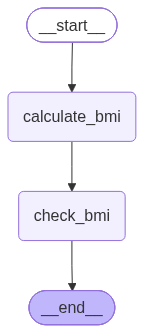

In [24]:
# display graph 
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))